# 13강. 워핑과 문서 스캐너

**2026-1 영상정보처리 | 김하연**

11강에서 배운 **아핀 변환**과 12강에서 배운 **투영 변환·보간법**을 OpenCV로 직접 구현해봅니다.

## 실습 목표
1. `getRotationMatrix2D`, `warpAffine`로 임의 점 기준 회전·스케일링
2. `getAffineTransform`로 점 3쌍 매핑
3. `getPerspectiveTransform`, `warpPerspective`로 투영 워핑
4. 보간법별 결과 비교 (Nearest / Bilinear / Bicubic)
5. 비스듬한 문서 사진 → 정면 변환 파이프라인 (자동 코너 검출)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import platform

# 한글 폰트 (환경에 맞게 자동 설정)
if platform.system() == 'Windows':
    rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    rcParams['font.family'] = 'AppleGothic'
else:
    rcParams['font.family'] = 'NanumGothic'
rcParams['axes.unicode_minus'] = False

print("OpenCV 버전:", cv2.__version__)


OpenCV 버전: 4.13.0


In [17]:
def show(imgs, titles, figsize=(15, 5)):
    """이미지를 한 줄로 나란히 출력하는 헬퍼"""
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap='gray')
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


---
## 0. 테스트 이미지 준비

샘플 이미지 파일이 있으면 사용하고, 없으면 합성 이미지로 진행합니다.


이미지 크기: 640 x 480


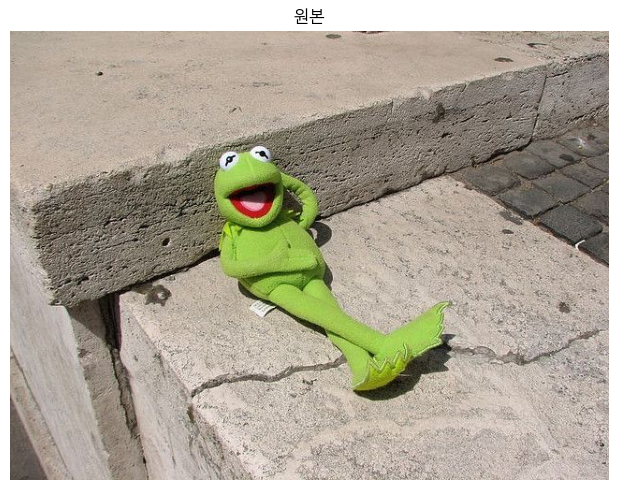

In [3]:
# 본인 이미지가 있으면 경로 지정, 없으면 자동 합성
img = cv2.imread('sample.jpg')

if img is None:
    # 합성 이미지: 배경 + 도형 + 텍스트
    img = np.full((400, 600, 3), 245, dtype=np.uint8)
    cv2.rectangle(img, (50, 50), (550, 350), (180, 100, 50), -1)
    cv2.circle(img, (300, 200), 70, (50, 200, 220), -1)
    cv2.putText(img, 'Visual Computing', (100, 380),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (30, 30, 30), 2)

h, w = img.shape[:2]
print(f"이미지 크기: {w} x {h}")
show([img], ['원본'], figsize=(8, 5))


---
## 1. 아핀 변환: `warpAffine`

11강 슬라이드 8 참고. 자유도 6의 일반형 아핀 행렬은 **2×3 행렬**로 표현됩니다.
OpenCV의 `warpAffine`은 마지막 행 `(0, 0, 1)`을 생략한 2×3 형태를 받습니다.

$$
\begin{bmatrix} x' \\ y' \end{bmatrix} =
\begin{bmatrix} a & b & t_x \\ c & d & t_y \end{bmatrix}
\begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$


### 1-1. 평행이동 (Translation)

`tx` 만큼 가로, `ty` 만큼 세로로 이동.


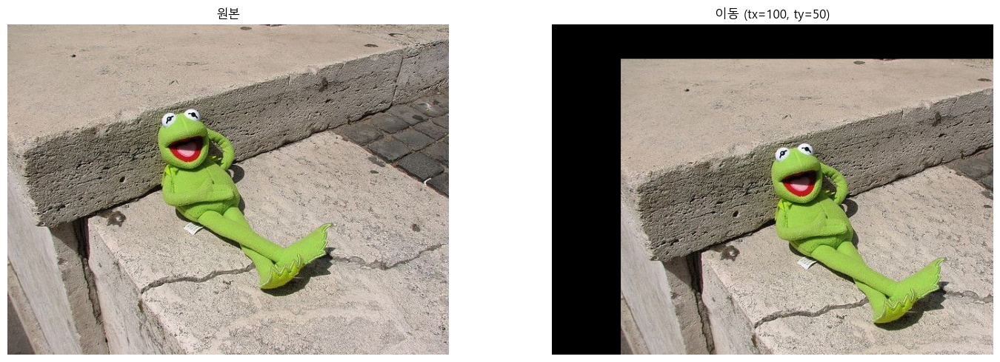

In [4]:
tx, ty = 100, 50
M = np.array([[1, 0, tx],
              [0, 1, ty]], dtype=np.float32)

dst = cv2.warpAffine(img, M, (w, h))
show([img, dst], ['원본', f'이동 (tx={tx}, ty={ty})'])


### 1-2. 원점 기준 회전

회전 행렬을 직접 작성. 원점(좌상단)을 기준으로 회전하므로 이미지가 화면 밖으로 빠집니다.


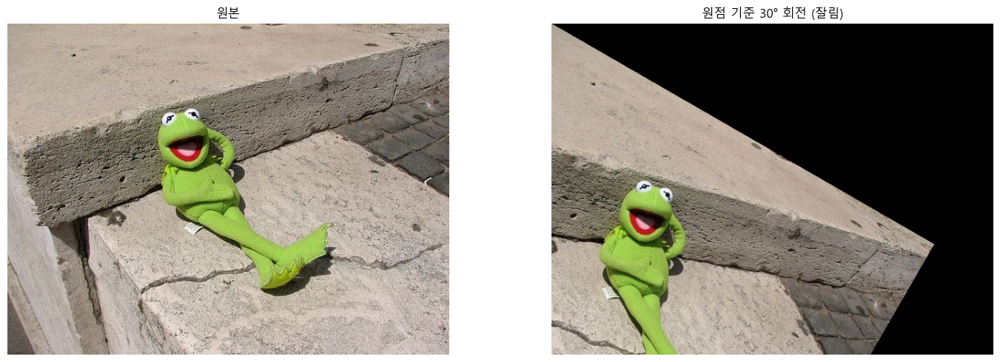

In [5]:
theta = np.deg2rad(30)  # 라디안 변환
R = np.array([[np.cos(theta), -np.sin(theta), 0],
              [np.sin(theta),  np.cos(theta), 0]], dtype=np.float32)

dst = cv2.warpAffine(img, R, (w, h))
show([img, dst], ['원본', '원점 기준 30° 회전 (잘림)'])


### 1-3. 임의 점 기준 회전 (이미지 중심)

11강 슬라이드 14에서 배운 합성 패턴:

$$M = T(c) \cdot R(\theta) \cdot T(-c)$$

OpenCV는 `cv2.getRotationMatrix2D(center, angle, scale)`로 이 합성을 한 번에 만들어줍니다.


회전 행렬 M =
[[  0.8660254    0.5        -77.12812921]
 [ -0.5          0.8660254  192.15390309]]


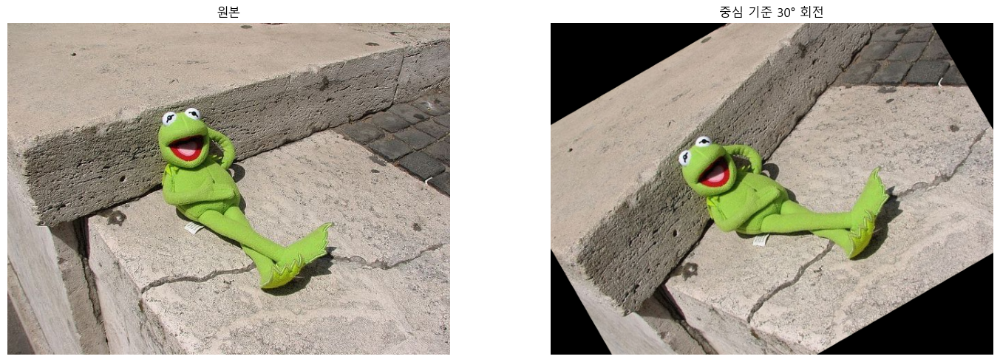

In [6]:
center = (w // 2, h // 2)  # 회전 중심 (이미지 중앙)
angle = 30                  # 회전 각도 (도 단위)
scale = 1.0                 # 배율

M = cv2.getRotationMatrix2D(center, angle, scale)
print("회전 행렬 M =")
print(M)

dst = cv2.warpAffine(img, M, (w, h))
show([img, dst], ['원본', '중심 기준 30° 회전'])


### 1-4. 회전 + 스케일링 동시 적용

`getRotationMatrix2D`의 세 번째 인자(scale)를 활용하면 회전과 스케일을 한 행렬로 합성할 수 있습니다.


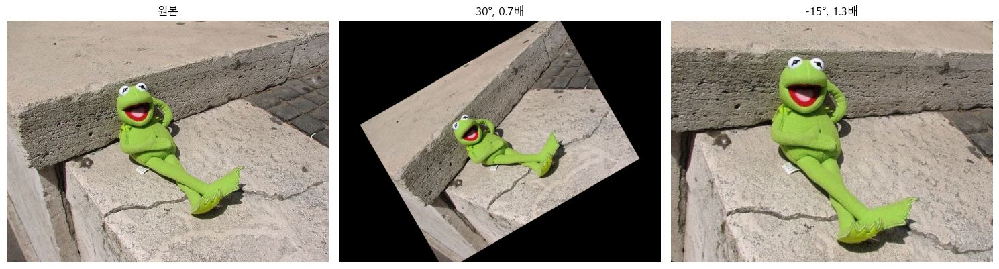

In [7]:
M_small = cv2.getRotationMatrix2D(center, 30, 0.7)   # 30° 회전 + 0.7배 축소
M_big   = cv2.getRotationMatrix2D(center, -15, 1.3)  # -15° 회전 + 1.3배 확대

dst_small = cv2.warpAffine(img, M_small, (w, h))
dst_big   = cv2.warpAffine(img, M_big, (w, h))

show([img, dst_small, dst_big],
     ['원본', '30°, 0.7배', '-15°, 1.3배'])


### 1-5. 점 3쌍으로 아핀 행렬 추정

자유도 6 → 점 3쌍이면 행렬을 결정 가능. `cv2.getAffineTransform(src, dst)`이 풀어줍니다.


아핀 행렬 M =
[[ 0.80125196  0.13361169 64.        ]
 [-0.11267606  0.75156576 96.        ]]


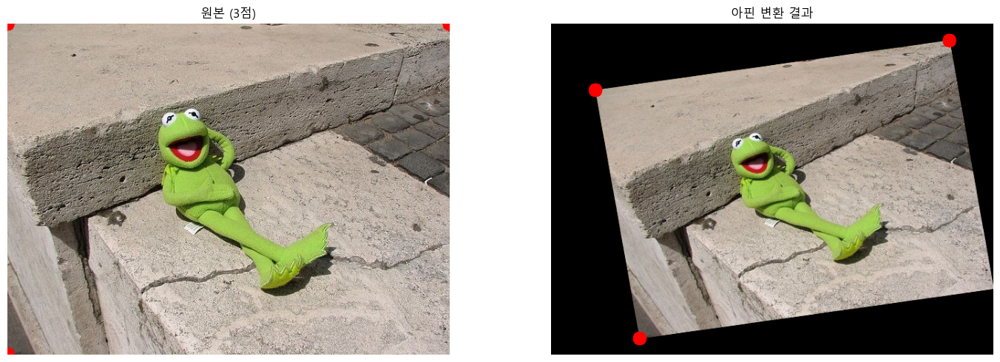

In [8]:
# 원본의 3점 → 목표 3점 매핑 지정
src_pts = np.float32([[0,     0],
                      [w-1,   0],
                      [0,     h-1]])

dst_pts = np.float32([[w*0.10, h*0.20],
                      [w*0.90, h*0.05],
                      [w*0.20, h*0.95]])

M = cv2.getAffineTransform(src_pts, dst_pts)
print("아핀 행렬 M =")
print(M)

dst = cv2.warpAffine(img, M, (w, h))

# 입력 점과 출력 점 시각화
vis_src = img.copy()
vis_dst = dst.copy()
for p in src_pts:
    cv2.circle(vis_src, tuple(p.astype(int)), 10, (0, 0, 255), -1)
for p in dst_pts:
    cv2.circle(vis_dst, tuple(p.astype(int)), 10, (0, 0, 255), -1)

show([vis_src, vis_dst], ['원본 (3점)', '아핀 변환 결과'])


---
## 2. 투영 변환: `warpPerspective`

12강에서 배운 호모그래피는 자유도 8의 **3×3 행렬**. 점 4쌍으로 결정됩니다.
아핀과 달리 평행성이 깨질 수 있어 **사다리꼴 ↔ 직사각형** 변환이 가능합니다.


호모그래피 행렬 M (3x3) =
[[ 5.00782473e-01 -3.34029228e-01  1.60000000e+02]
 [ 0.00000000e+00  5.00782473e-01  0.00000000e+00]
 [ 8.66149166e-20 -1.04220778e-03  1.00000000e+00]]


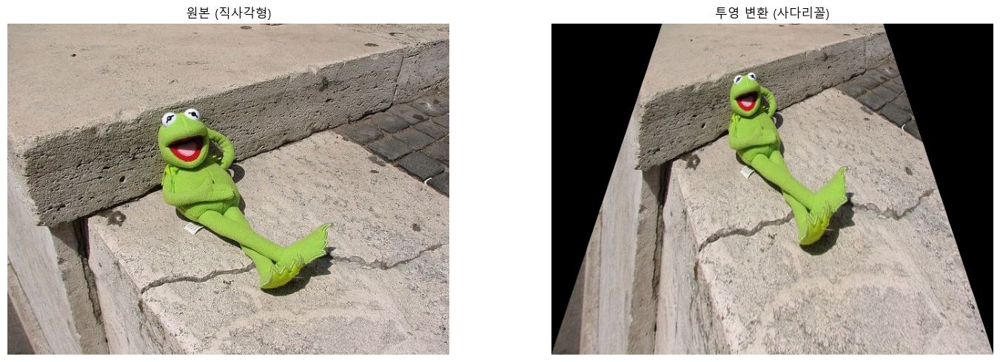

In [9]:
# 원본의 네 모서리 → 사다리꼴로 매핑
src_pts = np.float32([[0,   0],
                      [w-1, 0],
                      [w-1, h-1],
                      [0,   h-1]])

# 위쪽이 좁아지는 사다리꼴 (빌딩 올려다본 효과)
dst_pts = np.float32([[w*0.25, 0],
                      [w*0.75, 0],
                      [w-1,    h-1],
                      [0,      h-1]])

M = cv2.getPerspectiveTransform(src_pts, dst_pts)
print("호모그래피 행렬 M (3x3) =")
print(M)

dst = cv2.warpPerspective(img, M, (w, h))
show([img, dst], ['원본 (직사각형)', '투영 변환 (사다리꼴)'])


### 비교: 아핀 vs 투영

같은 4점에 대해 아핀(3점만 사용)과 투영(4점 모두 사용)의 결과가 어떻게 다른지 확인.
아핀은 평행성을 보존해야 하므로 사다리꼴을 만들 수 없습니다.


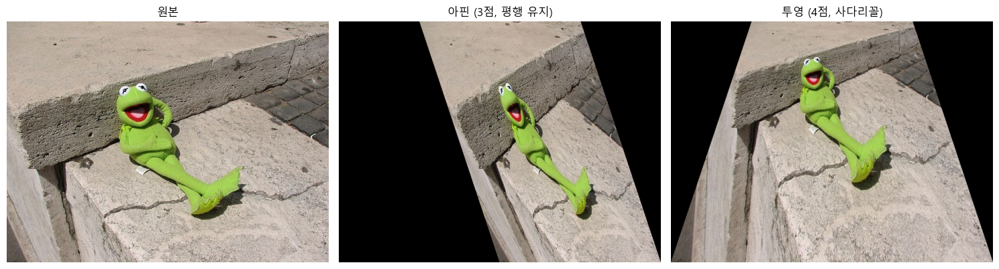

In [10]:
# 아핀: 첫 3점만 사용 (4번째 점은 평행성 때문에 자동 결정됨)
M_aff = cv2.getAffineTransform(src_pts[:3], dst_pts[:3])
dst_aff = cv2.warpAffine(img, M_aff, (w, h))

# 투영: 4점 모두 사용
M_per = cv2.getPerspectiveTransform(src_pts, dst_pts)
dst_per = cv2.warpPerspective(img, M_per, (w, h))

show([img, dst_aff, dst_per],
     ['원본', '아핀 (3점, 평행 유지)', '투영 (4점, 사다리꼴)'])


---
## 3. 보간법 비교

12강에서 배운 세 가지:
- `INTER_NEAREST`: 가장 가까운 정수 좌표 1개
- `INTER_LINEAR`: 주변 4개 픽셀 가중 평균 (Bilinear)
- `INTER_CUBIC`: 주변 16개 픽셀 3차 곡선 보간 (Bicubic)


### 3-1. 작은 이미지를 크게 확대

차이를 두드러지게 보기 위해 일부러 작은 이미지를 5배 확대.


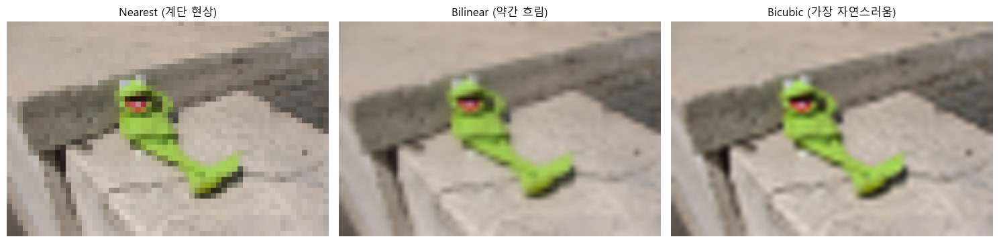

In [11]:
# 작게 다운샘플 후 다시 크게 업샘플
small = cv2.resize(img, (60, 40), interpolation=cv2.INTER_AREA)
target = (300, 200)

up_nn  = cv2.resize(small, target, interpolation=cv2.INTER_NEAREST)
up_bil = cv2.resize(small, target, interpolation=cv2.INTER_LINEAR)
up_bic = cv2.resize(small, target, interpolation=cv2.INTER_CUBIC)

show([up_nn, up_bil, up_bic],
     ['Nearest (계단 현상)', 'Bilinear (약간 흐림)', 'Bicubic (가장 자연스러움)'])


### 3-2. 회전에서의 보간법 차이

같은 회전 변환을 보간법만 바꿔서 적용. 회전 후 텍스트나 경계의 품질을 비교해보세요.


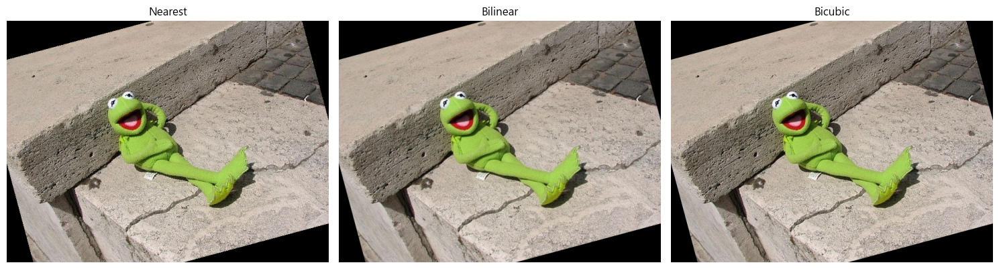

In [12]:
M = cv2.getRotationMatrix2D(center, 15, 1.0)

r_nn  = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_NEAREST)
r_bil = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR)
r_bic = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC)

show([r_nn, r_bil, r_bic],
     ['Nearest', 'Bilinear', 'Bicubic'])


---
## 4. 문서 스캐너 파이프라인

비스듬히 찍힌 문서 사진 → 정면에서 본 직사각형으로 변환.

### 전체 단계
1. **전처리**: 그레이스케일 → 가우시안 블러 → Canny 에지
2. **컨투어 검출**: `findContours`로 외곽선 추출
3. **사각형 근사**: `approxPolyDP`로 꼭짓점이 4개인 컨투어 찾기
4. **코너 정렬**: 좌상 → 우상 → 우하 → 좌하 순서로
5. **투영 변환**: `getPerspectiveTransform` + `warpPerspective`


### 4-1. 테스트 이미지 준비

비스듬한 문서 사진을 합성으로 만듭니다. 본인 사진 파일이 있다면 `cv2.imread('document.jpg')`로 교체하세요.


입력 사진 크기: 900 x 700


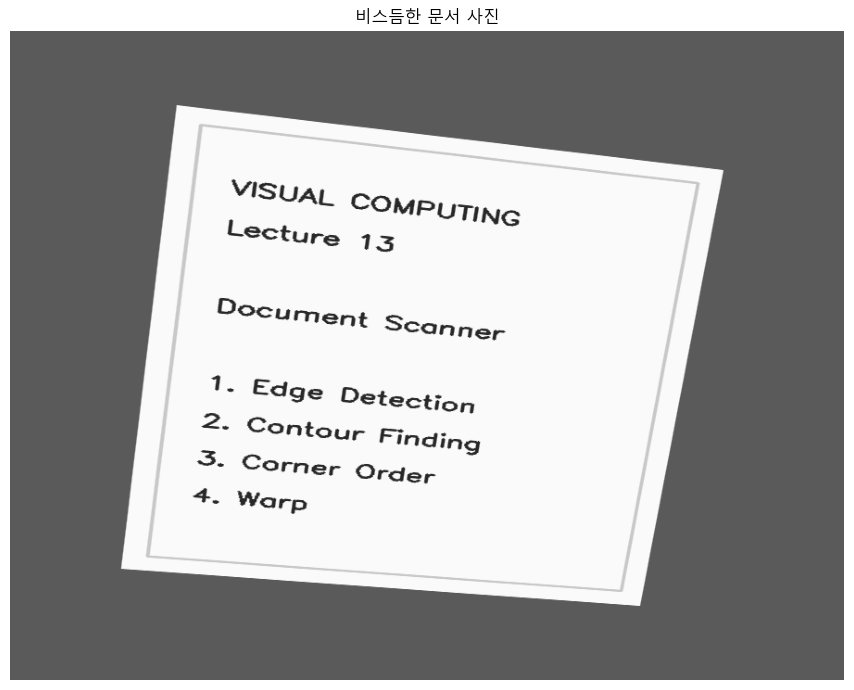

In [13]:
def make_skewed_doc():
    """테스트용 비스듬한 문서 사진 생성"""
    # 정면 문서
    doc = np.full((600, 450, 3), 250, dtype=np.uint8)
    cv2.rectangle(doc, (20, 20), (430, 580), (200, 200, 200), 2)
    lines = ["VISUAL COMPUTING", "Lecture 13", "",
             "Document Scanner", "", "1. Edge Detection",
             "2. Contour Finding", "3. Corner Order", "4. Warp"]
    for i, line in enumerate(lines):
        cv2.putText(doc, line, (50, 100 + i*50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (40, 40, 40), 2)
    
    # 어두운 배경 캔버스 위에 비스듬히 배치
    canvas = np.full((700, 900, 3), 90, dtype=np.uint8)
    src = np.float32([[0, 0], [450, 0], [450, 600], [0, 600]])
    dst = np.float32([[180, 80], [770, 150], [680, 620], [120, 580]])
    M = cv2.getPerspectiveTransform(src, dst)
    
    warped = cv2.warpPerspective(doc, M, (900, 700), borderValue=(90, 90, 90))
    mask = cv2.warpPerspective(np.ones((600, 450), np.uint8) * 255, M, (900, 700))
    canvas[mask > 0] = warped[mask > 0]
    return canvas

# 실제 사진을 사용하려면 주석을 바꾸세요
# photo = cv2.imread('document.jpg')
photo = make_skewed_doc()

H, W = photo.shape[:2]
print(f"입력 사진 크기: {W} x {H}")
show([photo], ['비스듬한 문서 사진'], figsize=(10, 7))


### 4-2. 전처리 + 에지 검출

- 그레이스케일: 색 정보 제거
- 가우시안 블러: 노이즈 억제 (Canny 안정화)
- Canny: 6강에서 배운 에지 검출


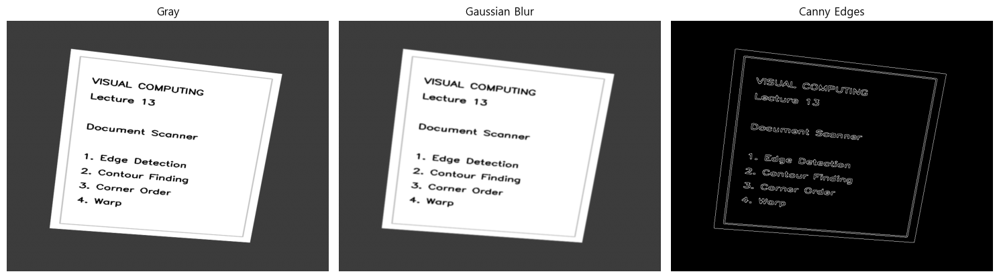

In [16]:
gray = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

show([gray, blur, edges],
     ['Gray', 'Gaussian Blur', 'Canny Edges'])


### 4-3. 컨투어 추출 → 가장 큰 사각형 찾기

- `findContours`: 외곽선 후보 추출
- 면적 큰 순으로 상위 N개만 후보로 추림
- `approxPolyDP`: 다각형 근사 → 꼭짓점이 정확히 4개면 사각형


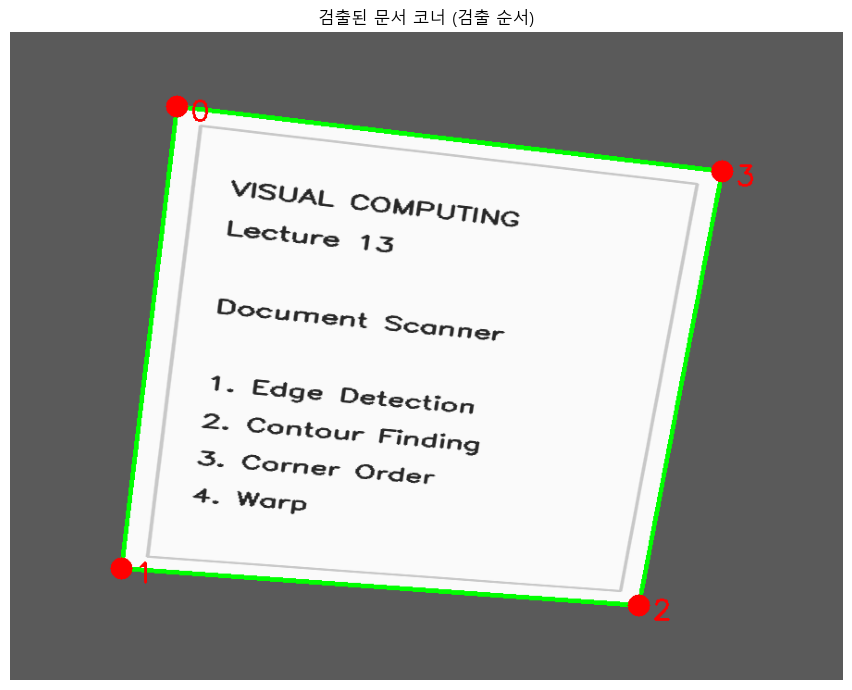

코너 좌표 (검출 순서):
[[180  80]
 [120 579]
 [679 619]
 [769 150]]


In [15]:
# 외곽 컨투어만 추출
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)

# 면적 큰 순서로 정렬, 상위 5개만 검사
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

doc_corners = None
for c in contours:
    peri = cv2.arcLength(c, closed=True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, closed=True)
    # 꼭짓점이 4개면 사각형으로 간주
    if len(approx) == 4:
        doc_corners = approx.reshape(4, 2)
        break

assert doc_corners is not None, "사각형 컨투어를 찾지 못했습니다."

# 검출 결과 시각화
vis = photo.copy()
cv2.drawContours(vis, [doc_corners.astype(int)], -1, (0, 255, 0), 4)
for i, p in enumerate(doc_corners):
    cv2.circle(vis, tuple(p.astype(int)), 12, (0, 0, 255), -1)
    cv2.putText(vis, str(i), tuple(p.astype(int) + np.array([15, 15])),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

show([vis], ['검출된 문서 코너 (검출 순서)'], figsize=(10, 7))
print("코너 좌표 (검출 순서):")
print(doc_corners)


### 4-4. 코너 정렬 (좌상 → 우상 → 우하 → 좌하)

`findContours`가 반환하는 점들의 순서는 일정하지 않으므로, 변환 전에 일관된 순서로 정렬해야 함.

**정렬 트릭**:
- 좌표 합 `(x + y)`: 최소 → 좌상(TL), 최대 → 우하(BR)
- 좌표 차 `(y - x)`: 최소 → 우상(TR), 최대 → 좌하(BL)


정렬된 코너 [TL, TR, BR, BL]:
[[180.  80.]
 [769. 150.]
 [679. 619.]
 [120. 579.]]


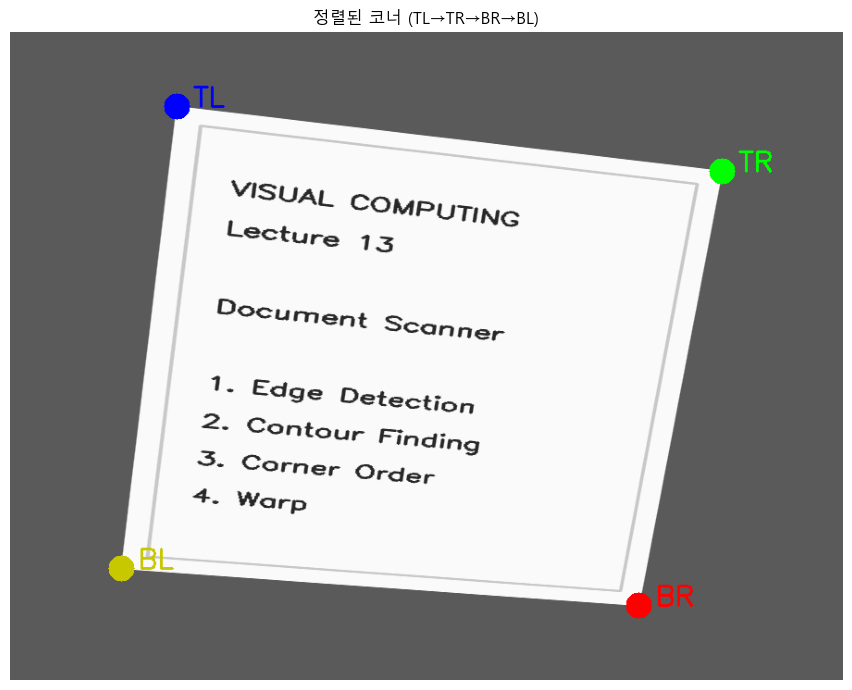

In [16]:
def order_corners(pts):
    """4개 점을 [TL, TR, BR, BL] 순서로 정렬"""
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)              # x + y
    d = np.diff(pts, axis=1).flatten()  # y - x
    
    rect[0] = pts[np.argmin(s)]  # TL: x+y 최소
    rect[2] = pts[np.argmax(s)]  # BR: x+y 최대
    rect[1] = pts[np.argmin(d)]  # TR: y-x 최소
    rect[3] = pts[np.argmax(d)]  # BL: y-x 최대
    return rect

ordered = order_corners(doc_corners.astype(np.float32))
print("정렬된 코너 [TL, TR, BR, BL]:")
print(ordered)

# 시각화
vis2 = photo.copy()
labels = ['TL', 'TR', 'BR', 'BL']
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (0, 200, 200)]
for p, label, color in zip(ordered, labels, colors):
    cv2.circle(vis2, tuple(p.astype(int)), 14, color, -1)
    cv2.putText(vis2, label, tuple(p.astype(int) + np.array([18, 0])),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)

show([vis2], ['정렬된 코너 (TL→TR→BR→BL)'], figsize=(10, 7))


### 4-5. 출력 크기 결정 + 투영 변환

원본 종이의 가로/세로 비율을 보존하기 위해, 검출된 사각형의 변 길이로 출력 크기를 추정.


출력 크기: 593 x 502


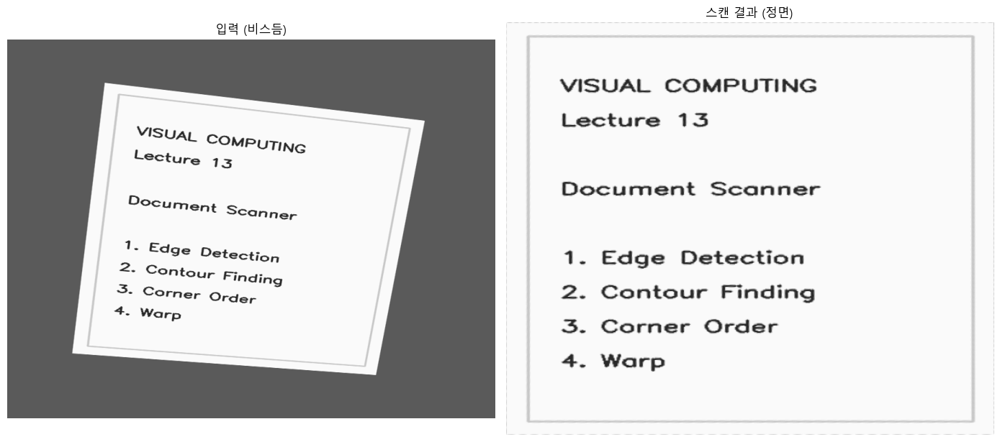

In [17]:
def warp_document(image, ordered_corners):
    """정렬된 4코너를 받아 정면 직사각형으로 워핑"""
    tl, tr, br, bl = ordered_corners
    
    # 출력 너비: 위/아래 변 중 긴 쪽
    width_top    = np.linalg.norm(tr - tl)
    width_bottom = np.linalg.norm(br - bl)
    out_w = int(max(width_top, width_bottom))
    
    # 출력 높이: 좌/우 변 중 긴 쪽
    height_left  = np.linalg.norm(bl - tl)
    height_right = np.linalg.norm(br - tr)
    out_h = int(max(height_left, height_right))
    
    # 목표 좌표는 깔끔한 직사각형
    dst = np.float32([[0,         0],
                      [out_w - 1, 0],
                      [out_w - 1, out_h - 1],
                      [0,         out_h - 1]])
    
    M = cv2.getPerspectiveTransform(ordered_corners, dst)
    warped = cv2.warpPerspective(image, M, (out_w, out_h))
    return warped

scanned = warp_document(photo, ordered)
print(f"출력 크기: {scanned.shape[1]} x {scanned.shape[0]}")

show([photo, scanned], ['입력 (비스듬)', '스캔 결과 (정면)'], figsize=(14, 7))


### 4-6. 후처리 (선택): 흑백 스캔 효과

스캔된 문서를 깔끔한 흑백 문서처럼 만들고 싶을 때 — 적응형 이진화 (8강 내용).


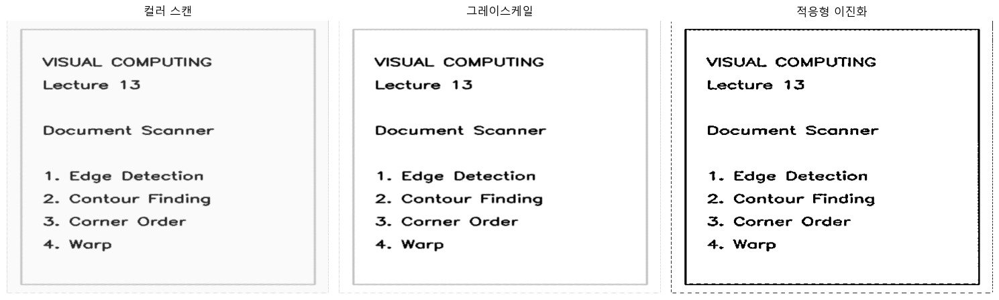

In [18]:
scanned_gray = cv2.cvtColor(scanned, cv2.COLOR_BGR2GRAY)
scanned_bin = cv2.adaptiveThreshold(
    scanned_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=21, C=10
)

show([scanned, scanned_gray, scanned_bin],
     ['컬러 스캔', '그레이스케일', '적응형 이진화'])


---
## 정리

| 함수 | 입력 행렬 | 자유도 | 필요한 점 쌍 |
|---|---|---|---|
| `warpAffine` | 2×3 | 6 | 3쌍 |
| `warpPerspective` | 3×3 | 8 | 4쌍 |

| 보간법 | 사용 픽셀 수 | 속도 | 용도 |
|---|---|---|---|
| `INTER_NEAREST` | 1 | 매우 빠름 | 라벨/마스크 |
| `INTER_LINEAR` | 4 | 빠름 | 일반 사진 (기본값) |
| `INTER_CUBIC` | 16 | 느림 | 인쇄용 고품질 |

**문서 스캐너 파이프라인**:
`Canny → findContours → approxPolyDP(4점) → order_corners → getPerspectiveTransform → warpPerspective`
